# Inspection of The Results

After all the experiments were ran, it is time to inspect and analyze the outcome. There will be 4 parts to that:
1. General inspection of constraint properties, excluding coverage and regularity. The subjects of the inspection will be 1) the distribution of the constraints by the type of linguistic information they employ; 2) the distribution of the application types of the constraints.
2. General inspection of the coverage and regularity measures. At this step, the obtained values will be analyzed, which includes their distribution and correlation.
3. Inspection of item against type measure distributions. This inspection focuses on how prone different covered noun classes are to outliers.
4. Inspection of the extent to which the claims about the constraints made in the literature are supported by the data. That includes manual comparison of the quantifiers specified in the constraint definitions ("regularly", "mostly" etc.) and the obtained type regularity values. We concentrate on the item variant since we want a more balanced estimation not affected by the outliers.

## 1. General Inspection of Constraint Properties

Our goal for this step of inspection is to retrieve the following:
1. The distribution of the constraints by the type of linguistic information they employ.
2. The distribution of the application items of the constraints.

Both properties are retrievable directly from the [master constraints file](../constraints.yaml) so we load and access it here.

In [2]:
import os
import pandas as pd
import yaml
from collections import defaultdict

In [3]:
with open("../../constraints/constraints.yaml", encoding="utf-8") as f:
    constraints: dict = list(yaml.safe_load_all(f))[-1]["constraints"]

### 1.1. Distribution of Constraints by Linguistic Information Type

Beside the linguistic info type, we will also distinguish between the application type (P2l/L2P).

In [4]:
pt1_out_dir = "../../../resources/custom/compounding/constraint_statistics/"

In [5]:
ling_type_data = {
    "p2l": defaultdict(int),
    "l2p": defaultdict(int)
}

for c_id, constraint in constraints.items():
    if c_id == "def-0": # disregard the default constraint
        continue
    ling_type = sorted(constraint["ling_info_type"])    # sort for multiple types
    ling_type_str = "+".join(ling_type)
    appl_type = c_id.split(":")[0]
    ling_type_data[appl_type][ling_type_str] += 1

ling_type_df = pd.DataFrame(
    data=ling_type_data
).fillna(0).astype(int).sort_index()

ling_type_df.to_csv(
    os.path.join(pt1_out_dir, "ling_type_df.tsv"),
    sep="\t",
    index=True,
    header=True
)
ling_type_df

,p2l,l2p
derivational,9,0
derivational+morphological+phonological,1,1
derivational+semantic,2,0
lexical,0,2
lexical+morphological,0,1
lexical+morphological+semantic,0,2
lexical+semantic,2,0
morphological,7,6
morphological+phonological,1,0
morphological+phonological+semantic,3,0


### 1.2. Distribution of Constraint Application Items

In [6]:
import matplotlib.pyplot as plt
from collections import Counter

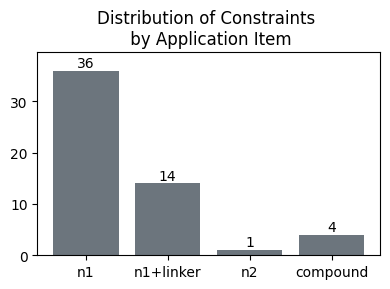

In [7]:
appl_items = [c["appl_item"] for c in constraints.values()]
order = ["n1", "n1+linker", "n2", "compound"]
counts = Counter(appl_items)
values = [counts[k] for k in order]

plt.figure(figsize=(4, 3))

bars = plt.bar(order, values, color="#6c757d")

# add count labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + max(values) * 0.02,
        f"{int(height)}",
        ha="center"
    )

# add headroom so labels don't collide with top border
plt.ylim(0, max(values) * 1.1)
plt.title("Distribution of Constraints \n by Application Item")
plt.tight_layout()

plt.savefig(
    os.path.join(pt1_out_dir, "appl_item_distr.png"),
    dpi=800
)
plt.show()

Additionally, we want to know which number of possible items each type has. For that, we need to access GeCoDB_v06.

In [8]:
gecodb_v06_path = "../../../resources/custom/compounding/intermediate_data/gecodb_v06.tsv"

gecodb_v06 = pd.read_csv(
    gecodb_v06_path,
    sep="\t",
    dtype=str,
    header=0,
    index_col="comp_gecodb"
)

In [9]:
gecodb_v06.head()

,comp_lemma,comp_freq,n1_lemma,n1_freq,n1_prod,n1_mass_freq,n2_lemma,n2_freq
comp_gecodb,,,,,,,,
land_kreis,Landkreis,2038715,land,8929250,1175,8243384,kreis,2731589
land_+es_regierung,Landesregierung,777779,land,8929250,1175,8243384,regierung,2648830
land_gericht,Landgericht,576177,land,8929250,1175,8243384,gericht,1784349
land_wirt,Landwirt,457461,land,8929250,1175,8243384,wirt,157625
land_+es_verband,Landesverband,210578,land,8929250,1175,8243384,verband,1138891


In [10]:
appl_item_counts = pd.Series(
    {
        "n1": len(gecodb_v06["n1_lemma"].unique()),
        "n1+linker": len((gecodb_v06["n1_lemma"] + gecodb_v06.index.to_frame()["comp_gecodb"].apply(
            lambda g: "_" if len(gs := g.split("_")) == 2 else gs[1]
        )).unique()),
        "n2": len(gecodb_v06["n2_lemma"].unique()),
        "compound": len(gecodb_v06)
    }
)

appl_item_counts.to_csv(
    os.path.join(pt1_out_dir, "appl_item_counts.tsv"),
    sep="\t",
    index=True,
    header=False
)
appl_item_counts

n1             3614
n1+linker      4894
n2             7214
compound     284192
dtype: int64

## 2. General Inspection of The Coverage and Regularity Measures

Here, we load the general applicability statistics table and retrieve three things:
1. Scatter plot of coverage against regularity in two variants (type, token). This graph serves provides both distributions of the measures and relation between them.
2. Analyze the distribution of the values closer.
3. Deviation measures of the obtained results. Serves as to further describe the distributions of the values.
4. Difference between the type and the token variants of the measures. Provides an idea of the gap between the linguistic and the usage statistics.

### 1.1. Draw Scatter Plots

In [11]:
pt2_out_dir = "../../../resources/custom/compounding/applicability_statistics"

In [12]:
stats_all = pd.read_csv(
    os.path.join(pt2_out_dir, "constr_statistics.tsv"),
    sep="\t",
    index_col=0,
    header=0
)

As we found out later, two of the constraints are unreliable and so we remove them from the inspection. We also drop constraints for which no data is available (semantic and lexical constraints).

In [13]:
unreliable_constr_ids = ["p2l:drv:sfx:F_#in$-en", "l2p:s|smpx_mn", "l2p:s|smpx_high_freq"]
stats = stats_all.drop(unreliable_constr_ids).dropna()
stats

,n_appl_items,quantifier,cvg_item,cvg_type,reg_item,reg_type
constr_id,,,,,,
def-0,284351.0,majority,1.000,1.000,0.578,0.578
p2l:decl_cl:pl:#0-0|def-0,3615.0,almost regularly,0.148,0.123,0.952,0.907
p2l:decl_cl:pl:#s-0,3615.0,regularly,0.035,0.033,0.963,0.953
p2l:decl_cl:pl:#e-0|def-0,3615.0,mostly,0.159,0.183,0.761,0.688
p2l:decl_cl:pl:#er-0/er|def-0/er,3615.0,mostly,0.019,0.058,0.828,0.867
p2l:decl_cl:pl:#e_uml-0|def-0,3615.0,mostly,0.080,0.110,0.720,0.756
p2l:decl_cl:pl:#0_uml-0|def-0,3615.0,mostly,0.007,0.015,0.943,0.965
p2l:decl_cl:mixed-0/s/en|def-0/s/en,3615.0,almost always,0.012,0.012,0.996,0.996
p2l:drv:sfx:0_pl_sfx-0,3615.0,regularly,0.071,0.045,0.983,0.967


Now draw the graphs.

KeyError: 'reg_token'

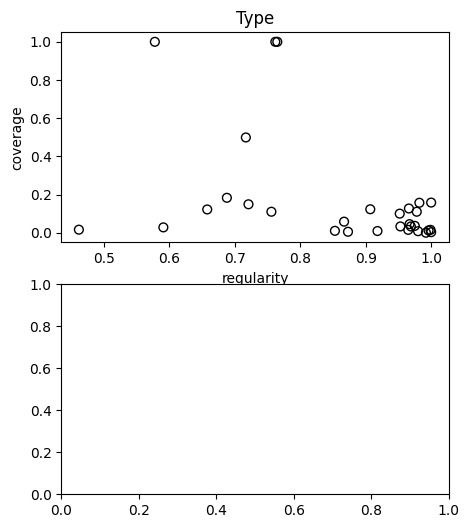

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(5, 6))

# first, type cov/reg values
axes[0].scatter(
    stats["reg_type"],
    stats["cvg_type"],
    facecolors="none",   # hollow inside
    edgecolors="black",  # outline
    s=40                 # marker size
)
axes[0].set_xlabel("regularity")
axes[0].set_ylabel("coverage")
axes[0].set_title("Type")


# first, token cov/reg values
axes[1].scatter(
    stats["reg_token"],
    stats["cvg_token"],
    facecolors="none",   # hollow inside
    edgecolors="black",  # outline
    s=40                 # marker size
)
axes[1].set_xlabel("regularity")
axes[1].set_ylabel("coverage")
axes[1].set_title("Token")


fig.suptitle(
    "Coverage and Regularity of \n"
    "German Nominal Compounding Constraints"
)

plt.tight_layout()
plt.savefig("cov_reg.png", dpi=1200)
plt.show()

### 1.2. Analyze The Distributions

Now, we check the numbers of different groups of constraints by their coverage and regularity. The groups are chosen by a visual inspection of the graph; the choice aims at a more illustrative representation of the results.

Coverage value groups.

In [ ]:
stats["cvg_type"].min(), stats["cvg_type"].max()

(np.float64(0.0), np.float64(1.0))

In [ ]:
stats["cvg_token"].min(), stats["cvg_token"].max()

(np.float64(0.0), np.float64(1.0))

Many of the coverage values are concentrated in the bottom of the graphs.

In [ ]:
stats[(stats["cvg_type"] < 0.2) & (stats["cvg_token"] < 0.2)]

,cvg_type,cvg_type_abs,cvg_token,cvg_token_abs,reg_type,reg_type_abs,reg_token,reg_token_abs
constr_id,,,,,,,,
p2l:decl_cl:pl:#0-0|def-0,0.123,52463.0,0.101,39049318.0,0.910,47757.0,0.793,30953757.0
p2l:decl_cl:pl:#s-0,0.032,13479.0,0.032,12432678.0,0.955,12872.0,0.974,12112968.0
p2l:decl_cl:pl:#e-0|def-0,0.182,77545.0,0.195,74919086.0,0.691,53611.0,0.686,51423356.0
p2l:decl_cl:pl:#er-0/er|def-0/er,0.056,23866.0,0.099,37991163.0,0.864,20622.0,0.766,29092638.0
p2l:decl_cl:pl:#e_uml-0|def-0,0.109,46231.0,0.134,51400096.0,0.755,34910.0,0.793,40773697.0
p2l:decl_cl:pl:#0_uml-0|def-0,0.012,4902.0,0.010,3767821.0,0.955,4683.0,0.956,3603919.0
p2l:decl_cl:mixed-0/s/en|def-0/s/en,0.012,5134.0,0.014,5543273.0,0.996,5111.0,0.990,5487772.0
p2l:drv:sfx:0_pl_sfx-0,0.045,18976.0,0.029,11034787.0,0.968,18362.0,0.906,9992479.0
p2l:drv:sfx:e_pl_sfx-0,0.005,2323.0,0.003,1277676.0,0.859,1996.0,0.941,1202391.0


In [ ]:
stats[(stats["cvg_type"] < 0.05) & (stats["cvg_token"] < 0.05)]

,cvg_type,cvg_type_abs,cvg_token,cvg_token_abs,reg_type,reg_type_abs,reg_token,reg_token_abs
constr_id,,,,,,,,
p2l:decl_cl:pl:#s-0,0.032,13479.0,0.032,12432678.0,0.955,12872.0,0.974,12112968.0
p2l:decl_cl:pl:#0_uml-0|def-0,0.012,4902.0,0.010,3767821.0,0.955,4683.0,0.956,3603919.0
p2l:decl_cl:mixed-0/s/en|def-0/s/en,0.012,5134.0,0.014,5543273.0,0.996,5111.0,0.990,5487772.0
p2l:drv:sfx:0_pl_sfx-0,0.045,18976.0,0.029,11034787.0,0.968,18362.0,0.906,9992479.0
p2l:drv:sfx:e_pl_sfx-0,0.005,2323.0,0.003,1277676.0,0.859,1996.0,0.941,1202391.0
p2l:drv:deverb_schwa$-0|def-0,0.028,11936.0,0.022,8468682.0,0.575,6869.0,0.734,6213841.0
p2l:drv:deadj_schwa$-0/en,0.010,4214.0,0.009,3445507.0,0.868,3659.0,0.904,3113944.0
p2l:drv:sfx:deverb_#en$-s,0.008,3536.0,0.011,4274706.0,0.913,3227.0,0.986,4212990.0
p2l:phon_fin:vow$-0,0.035,15031.0,0.028,10867264.0,0.971,14592.0,0.991,10767507.0


In [ ]:
stats[(stats["cvg_type"] < 0.01) & (stats["cvg_token"] < 0.01)]

,cvg_type,cvg_type_abs,cvg_token,cvg_token_abs,reg_type,reg_type_abs,reg_token,reg_token_abs
constr_id,,,,,,,,
p2l:drv:sfx:e_pl_sfx-0,0.005,2323.0,0.003,1277676.0,0.859,1996.0,0.941,1202391.0
l2p:e,0.008,3547.0,0.005,2082956.0,0.976,3462.0,0.993,2067815.0
l2p:e_uml,0.003,1093.0,0.002,679361.0,0.999,1092.0,1.000,679352.0
l2p:0_uml,0.000,192.0,0.000,59872.0,0.990,190.0,0.998,59743.0


Regularity value groups.

In [ ]:
stats["reg_type"].min(), stats["reg_type"].max()

(np.float64(0.165), np.float64(1.0))

In [ ]:
stats["reg_token"].min(), stats["reg_token"].max()

(np.float64(0.258), np.float64(1.0))

We see on the graph that there is an outlier by the regularity. Let's see the value range without it.

In [ ]:
outl_reg_type_idx = stats["reg_type"].argmin().item()
stats_no_outl_reg_type = stats.iloc[list(set(range(len(stats))) - {outl_reg_type_idx})]
stats_no_outl_reg_type["reg_type"].min(), stats_no_outl_reg_type["reg_type"].max()

(np.float64(0.573), np.float64(1.0))

In [ ]:
outl_reg_token_idx = stats["reg_token"].argmin().item()
stats_no_outl_reg_token = stats.iloc[list(set(range(len(stats))) - {outl_reg_token_idx})]
stats_no_outl_reg_token["reg_token"].min(), stats_no_outl_reg_token["reg_token"].max()

(np.float64(0.599), np.float64(1.0))

Now back to the groups. There is a visible shift of the values towards the right edge of the axis.

In [ ]:
stats[(stats["reg_type"] > 0.9) & (stats["reg_token"] > 0.9)]

,cvg_type,cvg_type_abs,cvg_token,cvg_token_abs,reg_type,reg_type_abs,reg_token,reg_token_abs
constr_id,,,,,,,,
p2l:decl_cl:pl:#s-0,0.032,13479.0,0.032,12432678.0,0.955,12872.0,0.974,12112968.0
p2l:decl_cl:pl:#0_uml-0|def-0,0.012,4902.0,0.010,3767821.0,0.955,4683.0,0.956,3603919.0
p2l:decl_cl:mixed-0/s/en|def-0/s/en,0.012,5134.0,0.014,5543273.0,0.996,5111.0,0.990,5487772.0
p2l:drv:sfx:0_pl_sfx-0,0.045,18976.0,0.029,11034787.0,0.968,18362.0,0.906,9992479.0
p2l:drv:sfx:sfx-s|def-s,0.144,61278.0,0.109,41842144.0,0.980,60041.0,0.986,41243912.0
p2l:drv:sfx:deverb_#en$-s,0.008,3536.0,0.011,4274706.0,0.913,3227.0,0.986,4212990.0
p2l:phon_fin:sibilant$-0,0.097,41270.0,0.095,36573549.0,0.951,39255.0,0.969,35454042.0
p2l:phon_fin:vow$-0,0.035,15031.0,0.028,10867264.0,0.971,14592.0,0.991,10767507.0
p2l:phon_fin:F_#stressed_phon$-0,0.032,13513.0,0.029,11121251.0,0.965,13034.0,0.979,10887065.0


In [ ]:
stats[(stats["reg_type"] > 0.98) & (stats["reg_token"] > 0.98)]

,cvg_type,cvg_type_abs,cvg_token,cvg_token_abs,reg_type,reg_type_abs,reg_token,reg_token_abs
constr_id,,,,,,,,
p2l:decl_cl:mixed-0/s/en|def-0/s/en,0.012,5134.0,0.014,5543273.0,0.996,5111.0,0.990,5487772.0
l2p:s|f,0.164,69825.0,0.138,53027970.0,1.000,69814.0,1.000,53025946.0
l2p:er,0.014,5881.0,0.012,4547874.0,0.999,5876.0,1.000,4546705.0
l2p:e_uml,0.003,1093.0,0.002,679361.0,0.999,1092.0,1.000,679352.0
l2p:0_uml,0.000,192.0,0.000,59872.0,0.990,190.0,0.998,59743.0


### 1.3. Compute Deviation Measures

Now, to further disclose the distribution of the values, we calculate their SDs.

In [ ]:
import numpy as np

In [ ]:
measure_sds = pd.DataFrame({
    "cvg": {
        "type": np.std(stats["cvg_type"]),
        "token": np.std(stats["cvg_token"])
    },
    "reg": {
        "type": np.std(stats["reg_type"]),
        "token": np.std(stats["reg_token"])
    }
})

measure_sds

,cvg,reg
type,0.293327,0.182415
token,0.297206,0.172361


### 1.4. Estimate The Difference Between The Type and The Token Variants

Here, we want to investigate how large the gap between the type and the token values for the same contrast is on average.

In [ ]:
from sklearn.metrics import mean_absolute_error

In [ ]:
type_token_maes = pd.Series({
    "cvg": mean_absolute_error(stats["cvg_type"], stats["cvg_token"]),
    "reg": mean_absolute_error(stats["reg_type"], stats["reg_token"])
})

type_token_maes

cvg    0.015333
reg    0.041500
dtype: float64

## 3. Inspection of Item Against Type Distributions

TODO

## 4. Inspection of The Extent to Which the Claims About the Constraints Made in The Literature Are Supported by The Data

The following steps are to be done for final inspection:
1. Manually inspect the support level of the claims in the empirical data. For each (analyzed) constraint, record the level of support. Since the definitions are mostly vague, base the decision on commonsense judgments. For the support level, we concentrate on the type variant of the measures since we focus on the linguistic side of the question (not real usage). There are 4 levels of support:
    * Supported. Full or very close correspondence between the quantifier and the empirical data. Examples: "regular" vs 0.99, "mostly" vs 0.75.
    * Partially supported. The gap is not critical yet noticeable. Examples: "regular" vs 0.93, "tends" vs 0.6, "sometimes" vs 0.9.
    * Not supported. The discrepancy between the quantifier and the empirical data is too significant to ignore. Examples: "regular" vs 0.85, "tends" vs 0.4.
    * NA: no data available (unreliable or semantic/lexical constraints).

Note: this steps is being conducted in the file with constraints definitions, see `compounding/constraints/constraints.yaml`. While it is being now made at the time of this inspection, we cannot reflect this processes here. After this step is done, we pull the results from this file and further inspect them in detail, specifically:

2. Inspect the distribution of the support levels.
3. Manually inspect the constraints that are only partially supported by the data or not supported at all.

### 4.1. Inspection of The Support Level

Done separately in `compounding/constraints/constraints.yaml`.

### 4.2. Inspection of Support Level Distribution

Now, we read the constraint definition file for inspection.

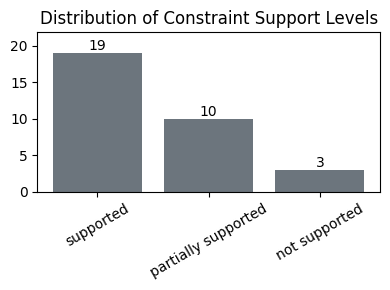

In [15]:
sup_levels = {
    c_id: sl for c_id, c in constraints.items()
    if (sl := c["support_level"]) != "NA"
}
order = ["supported", "partially supported", "not supported"] #, "NA"]
counts = Counter(sup_levels.values())
values = [counts[k] for k in order]

plt.figure(figsize=(4, 3))

bars = plt.bar(order, values, color="#6c757d")

# add count labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + max(values) * 0.02,
        f"{int(height)}",
        ha="center"
    )

# add headroom so labels don't collide with top border
plt.ylim(0, max(values) * 1.15)
plt.title("Distribution of Constraint Support Levels")
plt.xticks(rotation=30, ha="center")
plt.tight_layout()

plt.savefig(
    os.path.join(pt1_out_dir, "sup_level_distr.png"),
    dpi=800
)
plt.show()

### 4.3. Inspection of Partially / Not Supported Constraints

In [16]:
df = pd.read_csv(
    # the file needs to be extracted from zip
    os.path.join(pt2_out_dir, "appl_index.tsv"),
    sep="\t",
    index_col=0,
    header=0
)

/var/folders/_8/wwb5csy9605g6rl6wf4lcfch0000gr/T/ipykernel_62777/3135618284.py:1: DtypeWarning: Columns (6,9,12,21,36,42,48,54,57,60,66,69,75,81,84,87,90,93,96,123,126,129,132,135,138,147,150,153,162) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


In [17]:
def inspect_constr_appl(c_id: str, counterex: bool=True):
    subdf = df[df[c_id + "_is_applicable"]][[
        c_id + "_item",
        c_id + "_applies"
    ]]
    if counterex:
        subdf = subdf[subdf[c_id + "_applies"] == False]
        subdf = subdf[[c_id + "_item"]]   # applies always False
    items = subdf[c_id + "_item"].unique()
    example_dfs = []
    for item in items:
        items_subdf = subdf[subdf[c_id + "_item"] == item]
        l = len(items_subdf)
        m = min(l, 3)
        examples = items_subdf.sample(m)
        examples.insert(1, "n_bw_item", [l] * m)
        example_dfs.append(examples)
    examples_subdf = pd.concat(example_dfs, axis=0)
    examples_subdf.sort_values(by="n_bw_item", inplace=True, ascending=False)
    return subdf, examples_subdf

In [18]:
part_sup_ids = [
    c_id for c_id, sl in sup_levels.items()
    if sl == "partially supported"
]

part_sup_ids






part_sup_ids = [
    "p2l:decl_cl:pl:#s-0",
    "p2l:drv:sfx:e_pl_sfx-0",
    "p2l:drv:sfx:sfx-s|def-s",
    "p2l:drv:sfx:deverb_#en$-s",
    "p2l:phon_fin:vow$-0",
    "p2l:phon_fin:schwa$-en",
    "l2p:n",
    "l2p:en|par",
    "l2p:e",
    "l2p:er",
    "l2p:0_uml"
]

In [19]:
c_id = part_sup_ids[0]
subdf, examples_subdf = inspect_constr_appl(c_id)
examples_subdf

,p2l:decl_cl:pl:#s-0_item,n_bw_item
comp_gecodb,,
karneval_+s_zelt,karneval,194
karneval_+s_manier,karneval,194
karneval_+s_zubehör,karneval,194
fasching_+s_kalender,fasching,129
fasching_+s_anfang,fasching,129
fasching_+s_fahrt,fasching,129
interim_+s_verwalter,interim,64
interim_+s_halle,interim,64
interim_+s_unterbringung,interim,64


In [20]:
c_id = part_sup_ids[1]
subdf, examples_subdf = inspect_constr_appl(c_id)
examples_subdf

,p2l:drv:sfx:e_pl_sfx-0_item,n_bw_item
comp_gecodb,,
internat_+s_erzieher,internat,52
internat_+s_erziehung,internat,52
internat_+s_gebäude,internat,52
dekanat_+s_vorstand,dekanat,39
dekanat_+s_sekretärin,dekanat,39
dekanat_+s_treffen,dekanat,39
magistrat_+s_sitz,magistrat,31
magistrat_+s_rat,magistrat,31
magistrat_+s_sitzung,magistrat,31


In [21]:
c_id = part_sup_ids[2]
subdf, examples_subdf = inspect_constr_appl(c_id)
examples_subdf

,p2l:drv:sfx:sfx-s|def-s_item,n_bw_item
comp_gecodb,,
generation_+en_tag,generation,89
generation_+en_kluft,generation,89
generation_+en_arbeit,generation,89
wirtschaft_kriminalität,wirtschaft,51
wirtschaft_geschichte,wirtschaft,51
...,...,...
festung_sturm,festung,1
inflation_rate,inflation,1
schwangerschaft_abbruch,schwangerschaft,1


In [22]:
c_id = part_sup_ids[3]
subdf, examples_subdf = inspect_constr_appl(c_id)
examples_subdf

,p2l:drv:sfx:deverb_#en$-s_item,n_bw_item
comp_gecodb,,
essen_geld,essen,44
essen_marke,essen,44
essen_verkauf,essen,44
leben_lauf,leben,30
leben_sorte,leben,30
leben_versicherung,leben,30
braten_stein,braten,26
braten_geier,braten,26
braten_topf,braten,26


In [23]:
c_id = part_sup_ids[4]
subdf, examples_subdf = inspect_constr_appl(c_id)
examples_subdf

,p2l:phon_fin:vow$-0_item,n_bw_item
comp_gecodb,,
idee_+n_reise,idee,118
idee_+n_runde,idee,118
idee_+n_wand,idee,118
fee_+n_flügel,fee,39
fee_+n_krebs,fee,39
fee_+n_staub,fee,39
kalorie_+n_anzahl,kalorie,36
kalorie_+n_verlust,kalorie,36
kalorie_+n_abbau,kalorie,36


In [24]:
c_id = part_sup_ids[5]
subdf, examples_subdf = inspect_constr_appl(c_id)
examples_subdf

,p2l:phon_fin:schwa$-en_item,n_bw_item
comp_gecodb,,
reise_leitung,reise,511
reise_werbung,reise,511
reise_limousine,reise,511
liebe_+s_paradies,liebe,435
liebe_+s_qual,liebe,435
...,...,...
funke_lauge,funke,1
rinde_rohr,rinde,1
länge_feld,länge,1


In [27]:
c_id = part_sup_ids[6]
subdf, examples_subdf = inspect_constr_appl(c_id)
examples_subdf

,l2p:n_item,n_bw_item
comp_gecodb,,
oper_+n_star,oper_+n_,262
oper_+n_volk,oper_+n_,262
oper_+n_zentrum,oper_+n_,262
idee_+n_suche,idee_+n_,118
idee_+n_kiste,idee_+n_,118
...,...,...
zwiebel_+n_schneide,zwiebel_+n_,1
mauer_+n_straße,mauer_+n_,1
nachbar_+n_land,nachbar_+n_,1


In [47]:
c_id = part_sup_ids[7]
subdf, examples_subdf = inspect_constr_appl(c_id)
examples_subdf

,l2p:en|par_item,n_bw_item
comp_gecodb,,
oper_+n_freude,oper_+n_,262
oper_+n_karriere,oper_+n_,262
oper_+n_wunder,oper_+n_,262
stern_+en_decke,stern_+en_,199
stern_+en_deuter,stern_+en_,199
...,...,...
mauer_+n_straße,mauer_+n_,1
nachbar_+n_land,nachbar_+n_,1
wetter_+n_straße,wetter_+n_,1


In [49]:
c_id = part_sup_ids[8]
subdf, examples_subdf = inspect_constr_appl(c_id)
examples_subdf

,l2p:e_item,n_bw_item
comp_gecodb,,
anhalt_+e_versuch,anhalt_+e_,15
anhalt_+e_gebot,anhalt_+e_,15
anhalt_+e_aufforderung,anhalt_+e_,15
rest_+e_deponie,rest_+e_,13
rest_+e_markt,rest_+e_,13
rest_+e_kiste,rest_+e_,13
maus_+e_kind,maus_+e_,12
maus_+e_ohr,maus_+e_,12
maus_+e_zahn,maus_+e_,12


In [50]:
c_id = part_sup_ids[9]
subdf, examples_subdf = inspect_constr_appl(c_id)
examples_subdf

,l2p:er_item,n_bw_item
comp_gecodb,,
altertum_+=er_verwaltung,altertum_+=er_,3
altertum_+=er_sammlung,altertum_+=er_,3
altertum_+=er_behörde,altertum_+=er_,3
vorbild_+=er_sammlung,vorbild_+=er_,1
ding_+=er_mann,ding_+=er_,1
